In [1]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

GDP_PATH = "/Users/tonytony/Final Project/Data/Raw/gdp.csv"
META_PATH = "/Users/tonytony/Final Project/Data/Raw/world_bank_country_metadata.csv"

WINDOW_SIZE = 10

print("Libraries imported successfully")
print("GDP path:", GDP_PATH)
print("Metadata path:", META_PATH)
print("Rolling window size:", WINDOW_SIZE)


Libraries imported successfully
GDP path: /Users/tonytony/Final Project/Data/Raw/gdp.csv
Metadata path: /Users/tonytony/Final Project/Data/Raw/world_bank_country_metadata.csv
Rolling window size: 10


In [2]:
meta_df = pd.read_csv(META_PATH)

region_map = meta_df[[
    "Country Code",
    "World Bank Region"
]].copy().rename(columns={
    "Country Code": "country_code",
    "World Bank Region": "wb_region"
})

region_map["country_type"] = np.where(
    region_map["wb_region"].astype(str).str.strip().eq("Aggregates"),
    "Aggregate",
    "Country/Territory"
)

def load_wdi(path):
    df = pd.read_csv(path, skiprows=4)
    df = df.drop(
        columns=[col for col in df.columns if str(col).startswith("Unnamed")],
        errors="ignore"
    )
    year_cols = [col for col in df.columns if str(col).isdigit()]
    df[year_cols] = df[year_cols].apply(pd.to_numeric, errors="coerce")
    return df

def to_long(df, value_name):
    long_df = df.melt(
        id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        value_vars=[col for col in df.columns if str(col).isdigit()],
        var_name="year",
        value_name=value_name
    ).rename(columns={
        "Country Name": "country_name",
        "Country Code": "country_code",
        "Indicator Name": "indicator_name",
        "Indicator Code": "indicator_code"
    })

    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce").astype("int64")
    long_df[value_name] = pd.to_numeric(long_df[value_name], errors="coerce")
    return long_df

def add_region_info(long_df):
    merged = long_df.merge(region_map, on="country_code", how="left")
    merged = merged[merged["country_type"] == "Country/Territory"].copy()
    return merged

def forecast_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    non_zero_mask = y_true != 0
    if non_zero_mask.sum() > 0:
        mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
    else:
        mape = np.nan

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_pct": mape,
        "R_squared": r2
    }

print("Helper functions are ready")
region_map.head()


Helper functions are ready


,country_code,wb_region,country_type
0,ABW,Latin America & Caribbean,Country/Territory
1,AFE,Aggregates,Aggregate
2,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Country/Territory
3,AFR,Aggregates,Aggregate
4,AFW,Aggregates,Aggregate


In [3]:
gdp_raw = load_wdi(GDP_PATH)
gdp_long = add_region_info(to_long(gdp_raw, "gdp_per_capita_usd"))

gdp_long = gdp_long[
    (gdp_long["gdp_per_capita_usd"].notna()) &
    (gdp_long["gdp_per_capita_usd"] > 0)
].copy()

print("GDP long shape:", gdp_long.shape)
print("Countries:", gdp_long["country_code"].nunique())
print("Year range:", int(gdp_long["year"].min()), "-", int(gdp_long["year"].max()))

gdp_long.head()


GDP long shape: (11569, 8)
Countries: 214
Year range: 1960 - 2024


,country_name,country_code,indicator_name,indicator_code,year,gdp_per_capita_usd,wb_region,country_type
9,Argentina,ARG,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,778.251707,Latin America & Caribbean,Country/Territory
13,Australia,AUS,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,1813.431099,East Asia & Pacific,Country/Territory
14,Austria,AUT,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,939.914815,Europe & Central Asia,Country/Territory
16,Burundi,BDI,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,70.905100,Sub-Saharan Africa,Country/Territory
17,Belgium,BEL,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,1290.286072,Europe & Central Asia,Country/Territory


In [4]:
gdp_model_plan = pd.DataFrame({
    "Dataset": ["GDP", "GDP", "GDP"],
    "Candidate Model": ["Naive", "AutoReg", "ARIMA"],
    "Description": [
        "Uses the previous year's GDP as the forecast.",
        "Uses autoregressive dependence on previous GDP values.",
        "Uses differencing and autoregressive-moving-average structure."
    ]
})

gdp_model_plan


,Dataset,Candidate Model,Description
0,GDP,Naive,Uses the previous year's GDP as the forecast.
1,GDP,AutoReg,Uses autoregressive dependence on previous GDP...
2,GDP,ARIMA,Uses differencing and autoregressive-moving-av...


In [5]:
def one_step_gdp_forecast(window_values, model_name, autoreg_lags=3):
    series = pd.Series(window_values, dtype=float)

    if model_name == "Naive":
        return float(series.iloc[-1])

    if model_name == "AutoReg":
        lags = min(autoreg_lags, len(series) - 2)
        if lags < 1:
            return float(series.iloc[-1])

        fit = AutoReg(series, lags=lags, old_names=False, trend="c").fit()
        pred = fit.predict(start=len(series), end=len(series)).iloc[0]
        return float(pred)

    if model_name == "ARIMA":
        fit = ARIMA(
            series,
            order=(1, 1, 1),
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit()
        pred = fit.forecast(steps=1).iloc[0]
        return float(pred)

    raise ValueError(f"Unknown model: {model_name}")

def rolling_gdp_backtest(
    long_df,
    value_col="gdp_per_capita_usd",
    candidate_models=None,
    window_size=10,
    min_total_obs=15
):
    if candidate_models is None:
        candidate_models = ["Naive", "AutoReg", "ARIMA"]

    prediction_rows = []
    skipped_rows = []

    grouped = long_df[["country_name", "country_code", "wb_region", "year", value_col]].dropna().groupby("country_code")

    for country_code, group in grouped:
        group = group.sort_values("year").copy()

        if len(group) < max(min_total_obs, window_size + 1):
            skipped_rows.append({
                "country_code": country_code,
                "country_name": group["country_name"].iloc[0],
                "reason": "too_few_observations"
            })
            continue

        values = group[value_col].values.astype(float)
        years = group["year"].values.astype(int)
        country_name = group["country_name"].iloc[0]
        wb_region = group["wb_region"].iloc[0]

        for i in range(window_size, len(group)):
            train_window = values[i - window_size:i]
            actual_value = values[i]
            actual_year = int(years[i])

            for model_name in candidate_models:
                try:
                    predicted_value = one_step_gdp_forecast(
                        window_values=train_window,
                        model_name=model_name
                    )

                    prediction_rows.append({
                        "Dataset": "GDP",
                        "Model": model_name,
                        "country_code": country_code,
                        "country_name": country_name,
                        "wb_region": wb_region,
                        "year": actual_year,
                        "actual": actual_value,
                        "predicted": predicted_value
                    })

                except Exception as e:
                    skipped_rows.append({
                        "country_code": country_code,
                        "country_name": country_name,
                        "reason": f"{model_name} failed at year {actual_year}: {str(e)}"
                    })

    pred_df = pd.DataFrame(prediction_rows)
    skipped_df = pd.DataFrame(skipped_rows)

    summary_rows = []
    if not pred_df.empty:
        for model_name, temp in pred_df.groupby("Model"):
            metrics = forecast_metrics(temp["actual"], temp["predicted"])
            summary_rows.append({
                "Dataset": "GDP",
                "Model": model_name,
                **metrics,
                "n_predictions": len(temp),
                "n_countries_modeled": temp["country_code"].nunique()
            })

    summary_df = pd.DataFrame(summary_rows)
    return pred_df, summary_df, skipped_df

print("GDP backtest engine is ready")


GDP backtest engine is ready


In [6]:
gdp_predictions, gdp_summary, gdp_skipped = rolling_gdp_backtest(
    long_df=gdp_long,
    value_col="gdp_per_capita_usd",
    candidate_models=["Naive", "AutoReg", "ARIMA"],
    window_size=WINDOW_SIZE,
    min_total_obs=15
)

print("GDP candidate model results")
display(gdp_summary.round(4))

print("Skipped rows:", gdp_skipped.shape[0])
gdp_predictions.head()


GDP candidate model results


,Dataset,Model,MAE,RMSE,MAPE_pct,R_squared,n_predictions,n_countries_modeled
0,GDP,ARIMA,1052.4333,3126.3855,32.2211,0.9764,9437,212
1,GDP,AutoReg,1779.5435,8641.4526,59.9785,0.8199,9437,212
2,GDP,Naive,962.8993,2472.1792,15.3457,0.9853,9437,212


Skipped rows: 2


,Dataset,Model,country_code,country_name,wb_region,year,actual,predicted
0,GDP,Naive,ABW,Aruba,Latin America & Caribbean,1996,16620.954556,16548.717387
1,GDP,AutoReg,ABW,Aruba,Latin America & Caribbean,1996,16620.954556,16835.873252
2,GDP,ARIMA,ABW,Aruba,Latin America & Caribbean,1996,16620.954556,17086.275592
3,GDP,Naive,ABW,Aruba,Latin America & Caribbean,1997,17750.009564,16620.954556
4,GDP,AutoReg,ABW,Aruba,Latin America & Caribbean,1997,17750.009564,17466.837660


In [7]:
gdp_summary_sorted = gdp_summary.sort_values(["RMSE", "MAE", "MAPE_pct"]).reset_index(drop=True)
best_gdp_model = gdp_summary_sorted.head(1).copy()

print("Sorted GDP model results")
display(gdp_summary_sorted.round(4))

print("Best GDP model")
best_gdp_model.round(4)


Sorted GDP model results


,Dataset,Model,MAE,RMSE,MAPE_pct,R_squared,n_predictions,n_countries_modeled
0,GDP,Naive,962.8993,2472.1792,15.3457,0.9853,9437,212
1,GDP,ARIMA,1052.4333,3126.3855,32.2211,0.9764,9437,212
2,GDP,AutoReg,1779.5435,8641.4526,59.9785,0.8199,9437,212


Best GDP model


,Dataset,Model,MAE,RMSE,MAPE_pct,R_squared,n_predictions,n_countries_modeled
0,GDP,Naive,962.8993,2472.1792,15.3457,0.9853,9437,212


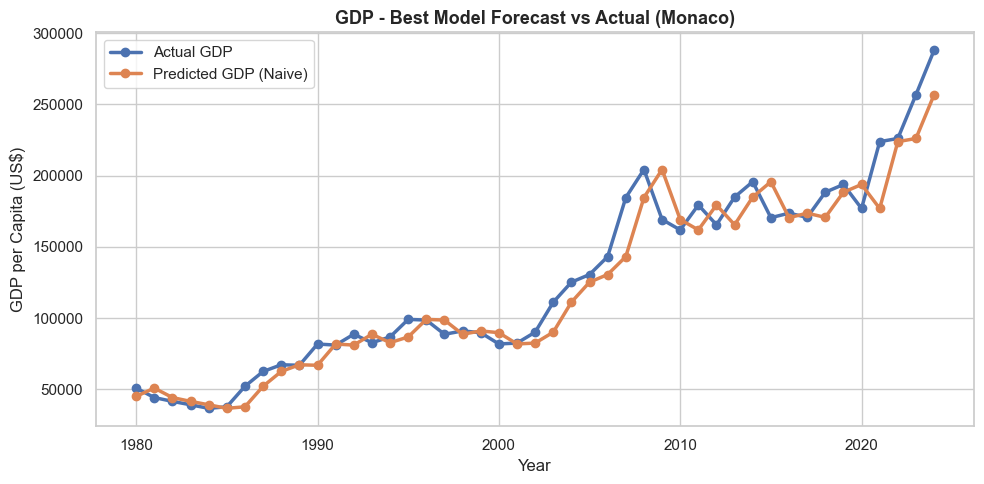

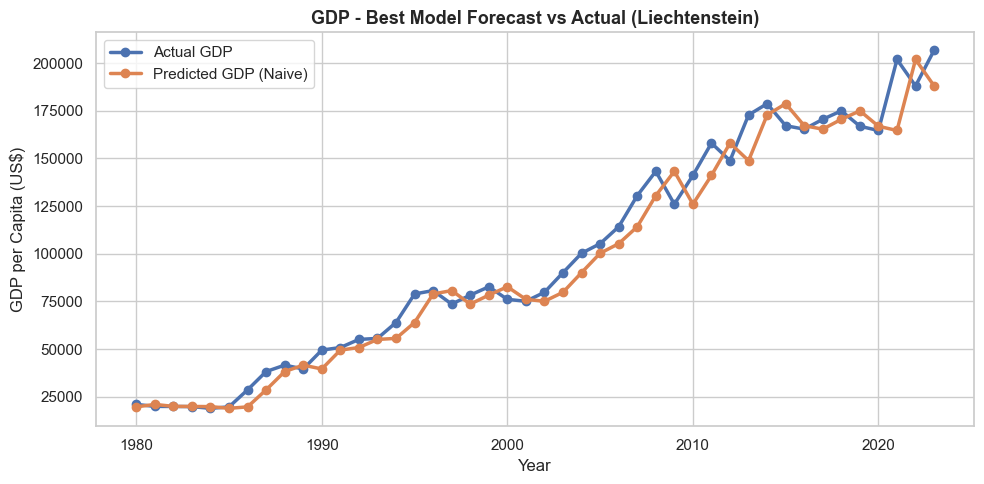

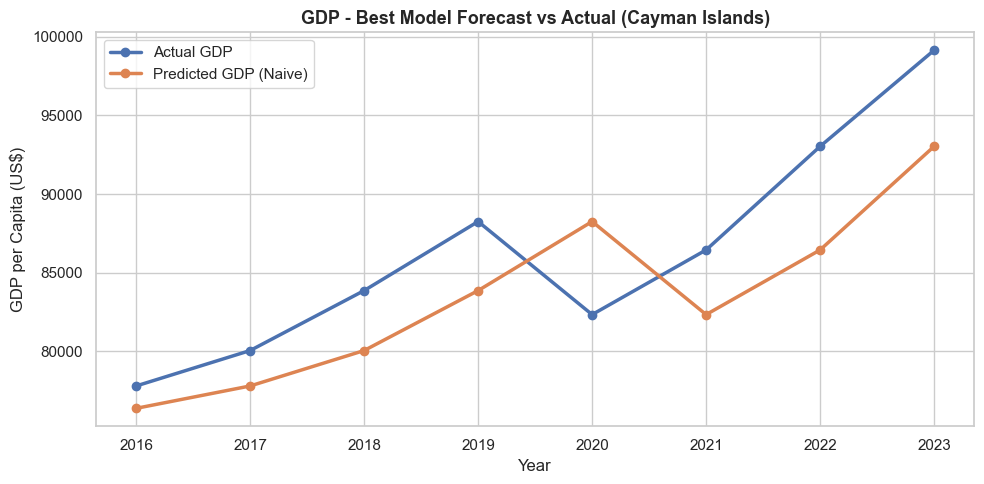

In [8]:
best_model_name = best_gdp_model["Model"].iloc[0]

best_gdp_predictions = gdp_predictions[
    gdp_predictions["Model"] == best_model_name
].copy()

sample_countries = (
    best_gdp_predictions.groupby(["country_code", "country_name"])["actual"]
    .mean()
    .sort_values(ascending=False)
    .head(3)
    .reset_index()
)

for _, row in sample_countries.iterrows():
    code = row["country_code"]
    name = row["country_name"]

    temp = best_gdp_predictions[
        best_gdp_predictions["country_code"] == code
    ].sort_values("year")

    plt.figure(figsize=(10, 5))
    plt.plot(temp["year"], temp["actual"], marker="o", linewidth=2.5, label="Actual GDP")
    plt.plot(temp["year"], temp["predicted"], marker="o", linewidth=2.5, label=f"Predicted GDP ({best_model_name})")

    plt.title(f"GDP - Best Model Forecast vs Actual ({name})", fontsize=13, fontweight="bold")
    plt.xlabel("Year")
    plt.ylabel("GDP per Capita (US$)")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [11]:
final_gdp_prediction_table = best_gdp_predictions[[
    "country_name",
    "country_code",
    "wb_region",
    "year",
    "actual",
    "predicted"
]].copy()

final_gdp_prediction_table.head(20)


,country_name,country_code,wb_region,year,actual,predicted
0,Aruba,ABW,Latin America & Caribbean,1996,16620.954556,16548.717387
3,Aruba,ABW,Latin America & Caribbean,1997,17750.009564,16620.954556
6,Aruba,ABW,Latin America & Caribbean,1998,18828.087059,17750.009564
9,Aruba,ABW,Latin America & Caribbean,1999,19216.197235,18828.087059
12,Aruba,ABW,Latin America & Caribbean,2000,20681.023027,19216.197235
15,Aruba,ABW,Latin America & Caribbean,2001,20740.132583,20681.023027
18,Aruba,ABW,Latin America & Caribbean,2002,21307.248251,20740.132583
21,Aruba,ABW,Latin America & Caribbean,2003,21949.485996,21307.248251
24,Aruba,ABW,Latin America & Caribbean,2004,23700.631990,21949.485996
27,Aruba,ABW,Latin America & Caribbean,2005,24171.837133,23700.631990


In [12]:
SAVE_GDP_SUMMARY_PATH = "/Users/tonytony/Final Project/Data/Cleaned/gdp_time_series_model_selection_summary_10y.csv"
SAVE_GDP_PREDICTIONS_PATH = "/Users/tonytony/Final Project/Data/Cleaned/gdp_time_series_model_selection_predictions_10y.csv"
SAVE_GDP_BEST_MODEL_PATH = "/Users/tonytony/Final Project/Data/Cleaned/gdp_time_series_best_model_10y.csv"

gdp_summary_sorted.to_csv(SAVE_GDP_SUMMARY_PATH, index=False)
final_gdp_prediction_table.to_csv(SAVE_GDP_PREDICTIONS_PATH, index=False)
best_gdp_model.to_csv(SAVE_GDP_BEST_MODEL_PATH, index=False)

print("Saved summary to:")
print(SAVE_GDP_SUMMARY_PATH)

print("\nSaved best-model predictions to:")
print(SAVE_GDP_PREDICTIONS_PATH)

print("\nSaved best-model row to:")
print(SAVE_GDP_BEST_MODEL_PATH)


Saved summary to:
/Users/tonytony/Final Project/Data/Cleaned/gdp_time_series_model_selection_summary_10y.csv

Saved best-model predictions to:
/Users/tonytony/Final Project/Data/Cleaned/gdp_time_series_model_selection_predictions_10y.csv

Saved best-model row to:
/Users/tonytony/Final Project/Data/Cleaned/gdp_time_series_best_model_10y.csv


In [ ]:
BEST_BACKTEST_MODEL = best_gdp_model["Model"].iloc[0]
FUTURE_PROJECTION_MODEL = "ARIMA"

projection_strategy = pd.DataFrame({
    "Stage": ["One-step rolling backtest", "Multi-year future projection"],
    "Model used": [BEST_BACKTEST_MODEL, FUTURE_PROJECTION_MODEL],
    "Why": [
        "Selected by the lowest one-step-ahead test error over rolling windows.",
        "Used for future GDP projection because ARIMA can extend trend and shock-adjusted dynamics better than a flat Naive recursion."
    ]
})

display(projection_strategy)

print("Best one-step backtest model:", BEST_BACKTEST_MODEL)
print("Future projection model:", FUTURE_PROJECTION_MODEL)
print("For direct future GDP paths, continue in future_forecasting_models.ipynb using ARIMA.")
